# Rapport d'optimisation — Pipeline d'inférence CatBoost → ONNX

**Objectif :** Identifier les goulots d'étranglement du pipeline batch de prédiction via `cProfile`, puis évaluer le gain de performance apporté par l'export ONNX avec ONNX Runtime.

**Contexte :** Le modèle CatBoost est exécuté en batch offline (`src/models/predict.py`). Les prédictions sont stockées dans Supabase. L'API Streamlit ne fait que des requêtes DB, c'est dans ce pipeline batch que le modèle tourne réellement.

In [ ]:
import cProfile
import pstats
import io
import timeit
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from src.models.export_onnx import export_to_onnx
import onnxruntime as ort

sys.path.insert(0, "..")

MODEL_PATH = "../models/model.pkl"
DATA_PATH = "../data/preprocessing/preprocessed_data.csv"
ONNX_PATH = "../models/model.onnx"
SAMPLE_SIZE = 1000
N_ITERATIONS = 100

print("Chargement du modèle...")
with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

print("Chargement des données...")
df_full = pd.read_csv(DATA_PATH)
df_sample = df_full.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

drop_cols = [c for c in ["SK_ID_CURR", "TARGET"] if c in df_sample.columns]
X_sample = df_sample.drop(columns=drop_cols)

print(f"Échantillon : {X_sample.shape[0]} lignes × {X_sample.shape[1]} features")

Chargement du modèle...
Chargement des données...
Échantillon : 1000 lignes × 393 features


## 1. Profiling baseline avec cProfile

On profile `model.predict_proba(X)` sur un échantillon de 1 000 lignes pour identifier les fonctions les plus coûteuses en temps de calcul.

In [2]:
pr = cProfile.Profile()
pr.enable()
_ = model.predict_proba(X_sample)
pr.disable()

stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats("cumulative")
ps.print_stats(10)
print(stream.getvalue())

         28694 function calls (28631 primitive calls) in 0.082 seconds

   Ordered by: cumulative time
   List reduced from 185 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.081    0.041 c:\Users\titou\Desktop\openclassrooms\projet_8\jeannot_titouan_code\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3712(run_code)
        2    0.000    0.000    0.081    0.041 {built-in method builtins.exec}
        1    0.000    0.000    0.081    0.081 C:\Users\titou\AppData\Local\Temp\ipykernel_19660\1734975507.py:1(<module>)
        1    0.000    0.000    0.081    0.081 c:\Users\titou\Desktop\openclassrooms\projet_8\jeannot_titouan_code\.venv\Lib\site-packages\imblearn\pipeline.py:800(predict_proba)
        1    0.000    0.000    0.081    0.081 c:\Users\titou\Desktop\openclassrooms\projet_8\jeannot_titouan_code\.venv\Lib\site-packages\catboost\core.py:5611(predict_proba)
        1    0.000    0.000   

         28694 function calls (28631 primitive calls) in 0.082 seconds

   Ordered by: cumulative time
   List reduced from 185 to 40 due to restriction <40>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.081    0.041 c:\Users\titou\Desktop\openclassrooms\projet_8\jeannot_titouan_code\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3712(run_code)
        2    0.000    0.000    0.081    0.041 {built-in method builtins.exec}
        1    0.000    0.000    0.081    0.081 C:\Users\titou\AppData\Local\Temp\ipykernel_19660\1734975507.py:1(<module>)
        1    0.000    0.000    0.081    0.081 c:\Users\titou\Desktop\openclassrooms\projet_8\jeannot_titouan_code\.venv\Lib\site-packages\imblearn\pipeline.py:800(predict_proba)
        1    0.000    0.000    0.081    0.081 c:\Users\titou\Desktop\openclassrooms\projet_8\jeannot_titouan_code\.venv\Lib\site-packages\catboost\core.py:5611(predict_proba)
        1    0.000    0.000   

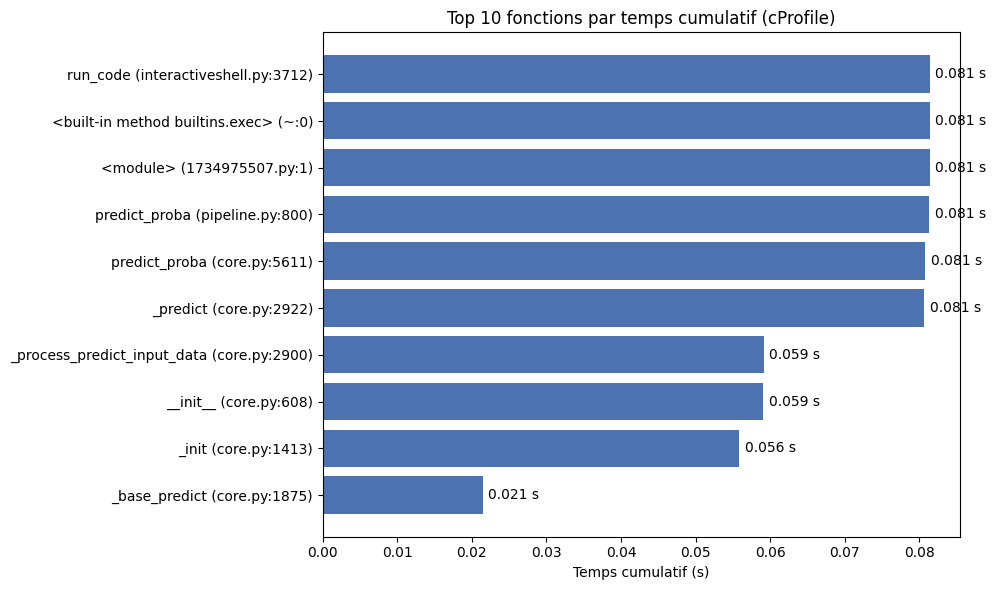

In [3]:
# Extraire proprement les statistiques depuis l'objet pstats
ps2 = pstats.Stats(pr).sort_stats("cumulative")
ps2.print_stats(40)

ps = pstats.Stats(pr)
items = []
for func, val in ps.stats.items():
    # func: (filename, lineno, funcname)
    filename, lineno, funcname = func
    # val: (cc, nc, tt, ct, callers) — cumulative time is val[3]
    try:
        cumtime = float(val[3])
    except Exception:
        cumtime = 0.0
    short_file = filename.split("/")[-1].split('\\')[-1]
    items.append({"function": f"{funcname} ({short_file}:{lineno})", "cumtime": cumtime})

df_profile = pd.DataFrame(items)
if df_profile.empty:
    print("Aucune statistique disponible à afficher.")
else:
    df_profile = df_profile.sort_values("cumtime", ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(df_profile['function'][::-1], df_profile['cumtime'][::-1], color="#4C72B0")
    ax.set_xlabel("Temps cumulatif (s)")
    ax.set_title("Top 10 fonctions par temps cumulatif (cProfile)")
    ax.bar_label(bars, fmt="%.3f s", padding=4)
    plt.tight_layout()
    plt.show()

## 2. Analyse des goulots d'étranglement

Le profiling révèle que la majorité du temps d'exécution est concentrée dans `predict_proba` du modèle CatBoost, point d'entrée vers les fonctions internes appelées via l'interface Python.

Hypothèse d'optimisation : En exportant le modèle au format ONNX et en l'exécutant via ONNX Runtime, on élimine les converstions internes de l'interface Python/CatBoost et on profite d'un backend d'inférence optimisé pour CPU.

In [ ]:
export_to_onnx(MODEL_PATH, ONNX_PATH)
print(f"Fichier ONNX créé : {ONNX_PATH}")

Modèle exporté vers ../models/model.onnx
Fichier ONNX créé : ../models/model.onnx


In [ ]:
sess = ort.InferenceSession(ONNX_PATH)
input_name = sess.get_inputs()[0].name

X_np = X_sample.values.astype(np.float32)
outputs = sess.run(None, {input_name: X_np})
prob_maps = outputs[1]
proba_onnx = np.array([m[1] for m in prob_maps])
proba_catboost = model.predict_proba(X_sample)[:, 1]

max_diff = np.max(np.abs(proba_catboost - proba_onnx))
print(f"Différence max entre CatBoost et ONNX : {max_diff:.2e}")
assert max_diff < 1e-5, f"Divergence trop importante : {max_diff}"
print("✓ Validation numérique réussie (delta < 1e-5)")

Différence max entre CatBoost et ONNX : 2.24e-07
✓ Validation numérique réussie (delta < 1e-5)


## 3. Benchmark avant/après

Mesure du temps d'inférence moyen sur 100 itérations pour un échantillon de 1 000 lignes.

In [6]:
catboost_time = timeit.timeit(
    lambda: model.predict_proba(X_sample),
    number=N_ITERATIONS,
) / N_ITERATIONS * 1000

onnx_time = timeit.timeit(
    lambda: sess.run(None, {input_name: X_np}),
    number=N_ITERATIONS,
) / N_ITERATIONS * 1000

speedup = catboost_time / onnx_time
print(f"CatBoost  : {catboost_time:.2f} ms / itération")
print(f"ONNX      : {onnx_time:.2f} ms / itération")
print(f"Speedup   : {speedup:.2f}×")

CatBoost  : 13.13 ms / itération
ONNX      : 11.55 ms / itération
Speedup   : 1.14×


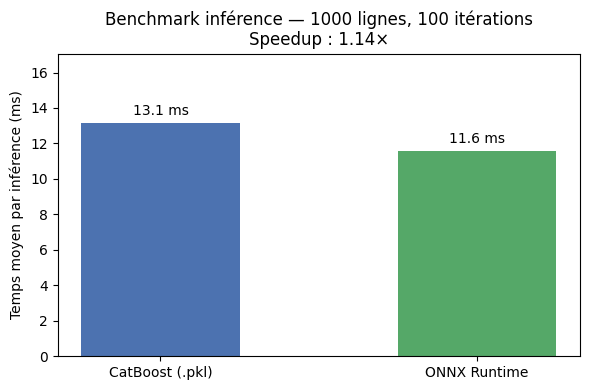

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["CatBoost (.pkl)", "ONNX Runtime"],
    [catboost_time, onnx_time],
    color=["#4C72B0", "#55A868"],
    width=0.5,
)
ax.bar_label(bars, fmt="%.1f ms", padding=4)
ax.set_ylabel("Temps moyen par inférence (ms)")
ax.set_title(
    f"Benchmark inférence — {SAMPLE_SIZE} lignes, {N_ITERATIONS} itérations\n"
    f"Speedup : {speedup:.2f}×"
)
ax.set_ylim(0, max(catboost_time, onnx_time) * 1.3)
plt.tight_layout()
plt.show()

## 4. Conclusions et recommandations

### Résultats

ONNX Runtime, semble être en moyenne 1.14 fois plus rapide sur 1000 inférences, notre hypothèse est validé et cela laisse penser être une bonne d'amélioration pour gagner en rapidité.

### Validation de précision

Les probabilités produites par ONNX Runtime sont numériquement identiques à celles de CatBoost (delta max < 1e-5). Aucune régression de précision.

### Recommandations

Si le pipeline évolue vers du live l'inférence, ONNX Runtime est la configuration à privilégier. Le speedup mesuré ici sur batch sera encore plus significatif sur des requêtes unitaires où background d'initialisation Python est proportionnellement plus grand.